This notebook contains the code used to produce summary tables used in [this analysis](https://public.flourish.studio/story/2586583/).

RQs:
- What is the distribution of contract type between occupations/sectors?
- What is the distribution of salary between occupations/sectors?
    - Avg annual increase by sector?
    - Stretch: hourly pay / annual pay / annualised pay?
- What proportion of ads in each occupation/sector mention learning and development/career progression/CPD?
- What proportion of ads in each occupation/sector mention flexible hours/flexible shifts?

Limitations:
- The sample only covers the years 2021-2023 inclusive

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from typing import List

from dap_job_quality import PROJECT_DIR, logger, BUCKET_NAME
from dap_job_quality.getters.data_getters import save_to_s3
from dap_job_quality.getters.keywords import get_keywords
from dap_job_quality.utils import analysis_utils

S3_OUT_PATH = 'job_quality/early_years/flourish_tables'

2024-09-23 10:59:28,817 - botocore.credentials - INFO - Found credentials in shared credentials file: ~/.aws/credentials


In [2]:
# Produced by pipeline/eyp/stratified_sample.py
afs_raw_sample = pd.read_parquet('s3://open-jobs-lake/job_quality/early_years/evaluation_sample/job_ads_by_sector_region_sample_size_19896.parquet')
# Produced by pipeline/find_job_quality.py
processed_ads = pd.read_parquet('s3://open-jobs-lake/job_quality/outputs/afs/job_ads_prod_True_n_19896.parquet')
# Produced by pipeline/eyp/extract_salaries.py
enhanced_salary_data = pd.read_parquet("s3://open-jobs-lake/job_quality/early_years/evaluation_sample/job_ads_by_sector_region_sample_size_19896_metadata_enhanced_salaries.parquet")

lookup = get_keywords()

2024-09-23 10:59:35,579 - aiobotocore.credentials - INFO - Found credentials in shared credentials file: ~/.aws/credentials


In [3]:
def process_afs_sample(afs_raw_sample):

    category_replacements = {
        'eyp': 'Early Years Practitioner',
        'non education': 'Waiter, Retail Assistant',
        'school teacher': 'Primary/Secondary School Teacher',
        'special needs teacher': 'Special Needs Teacher',
        'supply teacher': 'Supply Teacher',
        'teaching assistant': 'Teaching Assistant',
    }

    geo_replacements = {
        'london': 'London',
        'midlands': 'Midlands',
        'north': 'North',
        'south': 'South'
    }

    # Replace the categories in the column
    afs_raw_sample['sector_group'] = afs_raw_sample['sector_group'].replace(category_replacements)
    afs_raw_sample['geo'] = afs_raw_sample['geo'].replace(geo_replacements)
    afs_raw_sample['sector_group'].value_counts()
    logger.info(f"The complete sample includes {len(afs_raw_sample)} job adverts")
    logger.info(f"The sectors to which EYP roles are compared are: {afs_raw_sample['sector'].unique()}")
    sample_sector_by_itl = afs_raw_sample.groupby(['sector', 'itl_1_name']).agg('size').unstack(fill_value=0)
    logger.info(f'Distribution of sectors by ITL: {sample_sector_by_itl}')
    
    return afs_raw_sample

def process_jq_data(processed_ads):
    """
    Merge the processed job adverts with the lookup table to get the subcategory and dimension of the target phrase.
    
    Create a wide version of the data (dimensions_wide) with one row per job ID.
    """
    processed_ads = processed_ads[['id', 'sentences_split', 'target_phrase']].drop_duplicates()
    processed_ads = pd.merge(processed_ads, lookup[['target_phrase', 'subcategory','dimension']], on='target_phrase', how='left')
    dimensions_wide = analysis_utils.create_wide_table(processed_ads)
    
    return processed_ads, dimensions_wide

def merge_jq_data(afs_raw_sample, dimensions_wide):
    """
    Bring the metadata for the job ads together with the boolean job quality columns
    """
    afs_sample = pd.merge(afs_raw_sample, dimensions_wide, on='id', how='left')
    columns_to_replace = dimensions_wide.columns[2:] # the first column is the id
    # These columns have NaN where there are *no* mentions of JQ dimensions in these job adverts
    afs_sample[columns_to_replace] = afs_sample[columns_to_replace].fillna(0)
    return afs_sample

In [4]:
afs_raw_sample = process_afs_sample(afs_raw_sample)

2024-09-23 10:59:36,043 - dap_job_quality - INFO - The complete sample includes 19896 job adverts
2024-09-23 10:59:36,045 - dap_job_quality - INFO - The sectors to which EYP roles are compared are: ['Early Years Practitioner' 'Retail Assistant' 'Waiter'
 'Primary School Teacher' 'Secondary School Teacher'
 'Special Needs Teacher' 'Supply Teacher' 'Teaching Assistant']
2024-09-23 10:59:36,054 - dap_job_quality - INFO - Distribution of sectors by ITL: itl_1_name                East Midlands (England)  East of England  London  \
sector                                                                       
Early Years Practitioner                      251              161     829   
Primary School Teacher                        283              136     756   
Retail Assistant                              322              181     242   
Secondary School Teacher                       73               14      73   
Special Needs Teacher                         302              254     829   


In [5]:
processed_ads, dimensions_wide = process_jq_data(processed_ads)

In [6]:
afs_sample = merge_jq_data(afs_raw_sample, dimensions_wide)

# Analyse salary data

In [7]:
afs_sample_enhanced = pd.merge(afs_raw_sample, enhanced_salary_data[['id', 'raw_salary_unit', 'raw_salary_float', 'raw_min_salary_float', 'raw_max_salary_float','is_annualised']], on='id', how='left')

In [8]:
# Check that the merge was 1-1, and did not introduce duplicates
len(afs_sample_enhanced) - len(afs_raw_sample)

0

In [9]:
afs_sample_enhanced['raw_salary_unit'].value_counts()

raw_salary_unit
day     9942
year    3073
hour    2813
Name: count, dtype: int64

In [10]:
# Filter the data to only records that have some kind of salary rate unit
afs_sample_enhanced_w_salaries = afs_sample_enhanced[afs_sample_enhanced['raw_salary_unit'].notna()]
logger.info(f'N adverts lost because they did not contain salary data: {len(afs_sample_enhanced) - len(afs_sample_enhanced_w_salaries)} out of {len(afs_sample_enhanced)} leaving {len(afs_sample_enhanced_w_salaries)}')

2024-09-23 10:59:36,194 - dap_job_quality - INFO - N adverts lost because they did not contain salary data: 4068 out of 19896 leaving 15828


In [11]:
# proportion of ads offering hourly/daily/yearly salary
grouped = afs_sample_enhanced_w_salaries.groupby(['sector_group', 'raw_salary_unit']).size().unstack(fill_value=0)
grouped

raw_salary_unit,day,hour,year
sector_group,,,
Early Years Practitioner,818,876,984
Primary/Secondary School Teacher,2086,56,575
Special Needs Teacher,2043,59,700
Supply Teacher,2652,33,115
Teaching Assistant,2308,222,261
"Waiter, Retail Assistant",35,1567,438


In [12]:
grouped.to_csv('outputs/salary_unit_by_sector.csv')
save_to_s3(BUCKET_NAME, grouped, f'{S3_OUT_PATH}/salary_unit_by_sector.csv')

2024-09-23 10:59:36,314 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/early_years/flourish_tables/salary_unit_by_sector.csv ...


In [13]:
afs_sample_enhanced_w_salaries['raw_salary_float'] = afs_sample_enhanced_w_salaries['raw_salary_float'].fillna(afs_sample_enhanced_w_salaries['raw_min_salary_float'])

afs_sample_enhanced_w_salaries['hourly_wage'] = afs_sample_enhanced_w_salaries.apply(analysis_utils.calculate_hourly_wage, axis=1)

/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_88235/3219864542.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  afs_sample_enhanced_w_salaries['raw_salary_float'] = afs_sample_enhanced_w_salaries['raw_salary_float'].fillna(afs_sample_enhanced_w_salaries['raw_min_salary_float'])
/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_88235/3219864542.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  afs_sample_enhanced_w_salaries['hourly_wage'] = afs_sample_enhanced_w_salaries.apply(anal

In the next chunks we check the distribution of hourly wage and exclude outlying data.

In [14]:
afs_sample_enhanced_w_salaries['hourly_wage'].describe()

count    15828.000000
mean        13.687162
std          7.491473
min          0.000000
25%         10.000000
50%         13.186667
75%         16.000000
max        150.000000
Name: hourly_wage, dtype: float64

<Axes: >

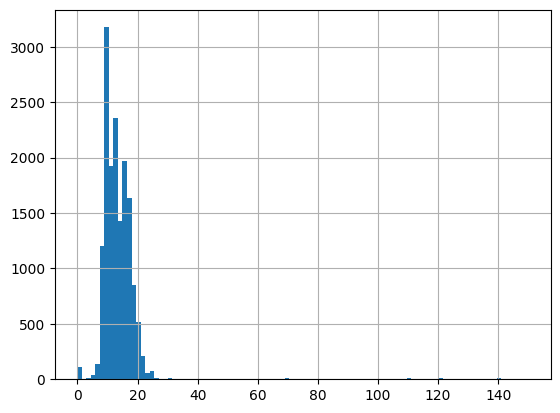

In [15]:
afs_sample_enhanced_w_salaries['hourly_wage'].hist(bins=100)

<Axes: >

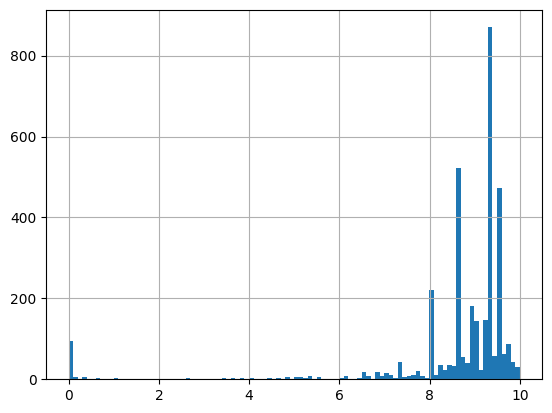

In [16]:
afs_sample_enhanced_w_salaries[afs_sample_enhanced_w_salaries['hourly_wage']<10]['hourly_wage'].hist(bins=100)

<Axes: >

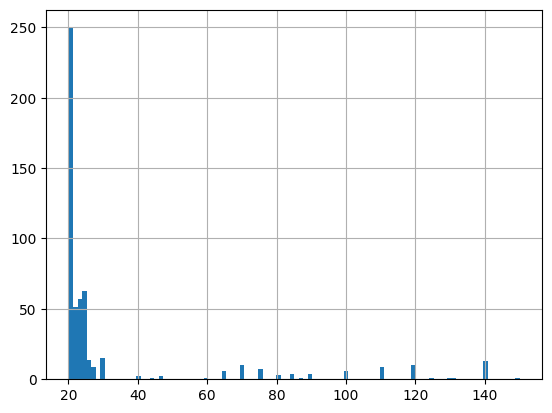

In [17]:
afs_sample_enhanced_w_salaries[afs_sample_enhanced_w_salaries['hourly_wage']>20]['hourly_wage'].hist(bins=100)

In [18]:
afs_sample_enhanced_w_salaries[(afs_sample_enhanced_w_salaries['hourly_wage']>40) & (afs_sample_enhanced_w_salaries['hourly_wage']<=100)]['sector'].value_counts()

sector
Teaching Assistant          19
Supply Teacher              11
Early Years Practitioner     9
Primary School Teacher       4
Special Needs Teacher        2
Name: count, dtype: int64

In [19]:
# Remove outlying salaries from the data.
# The minimum wage for 16 year olds in 2023 was £5.28 so realistically there shouldn't be hourly pay much lower than this.
# Any hourly pay above £40 is also likely to be an error.
afs_sample_enhanced_w_salaries = afs_sample_enhanced_w_salaries[(afs_sample_enhanced_w_salaries['hourly_wage']>=5)&(afs_sample_enhanced_w_salaries['hourly_wage']<40)]

# Salaries by sector and geo

## Export data for slide 2

In [21]:
# Export data for the boxplot of hourly wage by sector
afs_sample_enhanced_w_salaries[['id', 'sector_group', 'hourly_wage']].to_csv('outputs/salary_boxplot.csv')
save_to_s3(BUCKET_NAME, afs_sample_enhanced_w_salaries[['id', 'sector_group', 'hourly_wage']], f'{S3_OUT_PATH}/salary_boxplot.csv')

2024-09-23 11:00:37,264 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/early_years/flourish_tables/salary_boxplot.csv ...


In [22]:
afs_sample_enhanced_w_salaries['hourly_wage'].median()

13.333333333333334

In [23]:
afs_sample_enhanced_w_salaries.groupby('sector_group')['hourly_wage'].describe()

,count,mean,std,min,25%,50%,75%,max
sector_group,,,,,,,,
Early Years Practitioner,2646.0,11.290478,2.875950,5.010000,9.333333,10.650897,12.307692,26.666667
Primary/Secondary School Teacher,2693.0,15.686177,2.666677,6.153846,13.692000,16.000000,17.333333,30.000000
Special Needs Teacher,2773.0,16.369333,3.279597,7.384615,13.819487,16.000000,18.666667,30.000000
Supply Teacher,2775.0,15.509819,2.470481,6.144000,13.333333,16.000000,17.333333,30.000000
Teaching Assistant,2762.0,9.751079,1.326231,5.280000,8.912500,9.333333,10.666667,25.000000
"Waiter, Retail Assistant",1954.0,10.733637,1.928671,5.000000,9.550000,10.256410,11.794872,26.666667


## Output for slide 3 (median pay by region)

In [24]:
geo_median_wage = afs_sample_enhanced_w_salaries.groupby('geo').agg({'hourly_wage': ['median', 'std', 'min', 'max']}).reset_index()
geo_median_wage.to_csv('outputs/geo_median_wage.csv', index=False)
save_to_s3(BUCKET_NAME, geo_median_wage, f'{S3_OUT_PATH}/geo_median_wage.csv')
geo_median_wage

2024-09-23 11:02:13,832 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/early_years/flourish_tables/geo_median_wage.csv ...


geo hourly_wage                               
                 median       std       min        max
0    London   15.333333  4.119844  5.128205  26.933333
1  Midlands   13.333333  3.478781  5.000000  26.666667
2     North   12.220000  3.392470  5.010000  30.000000
3     South   12.820513  3.455887  5.128205  30.000000

## Output for slide 5 (boxplot of hourly pay by sector/geo)

In [26]:
afs_sample_enhanced_w_salaries[['geo', 'sector_group', 'hourly_wage']].to_csv('outputs/geo_sector_hourly_wage_boxplot.csv')
save_to_s3(BUCKET_NAME, afs_sample_enhanced_w_salaries[['geo', 'sector_group', 'hourly_wage']], f'{S3_OUT_PATH}/geo_sector_hourly_wage_boxplot.csv')

2024-09-23 11:03:30,549 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/early_years/flourish_tables/geo_sector_hourly_wage_boxplot.csv ...


## Output for slide 4 (median pay by sector and geo)

In [27]:
geo_median_wage_sector = afs_sample_enhanced_w_salaries.groupby(['geo', 'sector_group']).agg({'hourly_wage':'median'}).unstack(fill_value=0).reset_index()
geo_median_wage_sector.to_csv('outputs/geo_median_wage_sector.csv', index=False)
save_to_s3(BUCKET_NAME, geo_median_wage_sector, f'{S3_OUT_PATH}/geo_median_wage_sector.csv')
geo_median_wage_sector

2024-09-23 11:04:10,534 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/early_years/flourish_tables/geo_median_wage_sector.csv ...


geo              hourly_wage  \
sector_group           Early Years Practitioner   
0               London                10.769231   
1             Midlands                10.650000   
2                North                10.037821   
3                South                10.666667   

                                                                     \
sector_group Primary/Secondary School Teacher Special Needs Teacher   
0                                   17.333333             18.666667   
1                                   15.333333             16.000000   
2                                   14.666667             16.000000   
3                                   14.666667             14.666667   

                                                                         
sector_group Supply Teacher Teaching Assistant Waiter, Retail Assistant  
0                 17.333333          10.000000                   11.550  
1                 14.666667           9.333333                    9.610  
2                 14.666667           9.333333                    9.925  
3                 16.000000           9.333333                   10.220

# Comparison of multiple dimensions across sectors

In [28]:
afs_sample_enhanced_w_salaries_dimensions = pd.merge(afs_sample_enhanced_w_salaries, dimensions_wide, on='id', how='left')
len(afs_sample_enhanced_w_salaries_dimensions) - len(afs_sample_enhanced_w_salaries)

0

In [29]:
prop_table = afs_sample_enhanced_w_salaries_dimensions.groupby(['sector_group']).agg({'FLEX_HOURS': sum, 'L&D': sum, 'CAREER': sum,'id': 'size', 'hourly_wage': 'median'}).reset_index()

for dim in ['FLEX_HOURS', 'L&D', 'CAREER']:
    prop_table[f'{dim}_perc'] = (prop_table[dim] / prop_table['id']) * 100

prop_table

/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_88235/2029450194.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  prop_table = afs_sample_enhanced_w_salaries_dimensions.groupby(['sector_group']).agg({'FLEX_HOURS': sum, 'L&D': sum, 'CAREER': sum,'id': 'size', 'hourly_wage': 'median'}).reset_index()
/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_88235/2029450194.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  prop_table = afs_sample_enhanced_w_salaries_dimensions.groupby(['sector_group']).agg({'FLEX_HOURS': sum, 'L&D': sum, 'CAREER': sum,'id': 'size', 'hourly_wage': 'median'}).reset_index()


,sector_group,FLEX_HOURS,L&D,CAREER,id,hourly_wage,FLEX_HOURS_perc,L&D_perc,CAREER_perc
0,Early Years Practitioner,402.0,1067.0,296.0,2646,10.650897,15.192744,40.325019,11.186697
1,Primary/Secondary School Teacher,414.0,1030.0,206.0,2693,16.000000,15.373190,38.247308,7.649462
2,Special Needs Teacher,119.0,855.0,132.0,2773,16.000000,4.291381,30.833033,4.760188
3,Supply Teacher,765.0,745.0,96.0,2775,16.000000,27.567568,26.846847,3.459459
4,Teaching Assistant,204.0,1091.0,148.0,2762,9.333333,7.385952,39.500362,5.358436
5,"Waiter, Retail Assistant",338.0,268.0,111.0,1954,10.256410,17.297851,13.715455,5.680655


## Output for slide 6

In [30]:
prop_table[['sector_group', 'id', 'hourly_wage', 'CAREER_perc', 'FLEX_HOURS_perc', 'L&D_perc']].to_csv('outputs/sector_multi_comparison.csv')
save_to_s3(BUCKET_NAME, prop_table[['sector_group', 'id', 'hourly_wage', 'CAREER_perc', 'FLEX_HOURS_perc', 'L&D_perc']], f'{S3_OUT_PATH}/sector_multi_comparison.csv')

2024-09-23 11:06:47,026 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/early_years/flourish_tables/sector_multi_comparison.csv ...


## Output for slide 7

In [31]:
geo_prop_table = afs_sample_enhanced_w_salaries_dimensions.groupby(['geo','sector_group']).agg({'FLEX_HOURS': sum, 'L&D': sum, 'CAREER': sum,'id': 'size', 'hourly_wage': 'median'}).reset_index()

for dim in ['CAREER', 'FLEX_HOURS', 'L&D']:
    geo_prop_table[f'{dim}_perc'] = (geo_prop_table[dim] / geo_prop_table['id']) * 100

geo_prop_table[['sector_group', 'geo','id', 'hourly_wage', 'CAREER_perc', 'FLEX_HOURS_perc', 'L&D_perc']].to_csv('outputs/sector_geo_multi_comparison.csv')
save_to_s3(BUCKET_NAME, geo_prop_table[['sector_group', 'geo','id', 'hourly_wage', 'CAREER_perc', 'FLEX_HOURS_perc', 'L&D_perc']], f'{S3_OUT_PATH}/sector_geo_multi_comparison.csv')
geo_prop_table

/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_88235/1588502114.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  geo_prop_table = afs_sample_enhanced_w_salaries_dimensions.groupby(['geo','sector_group']).agg({'FLEX_HOURS': sum, 'L&D': sum, 'CAREER': sum,'id': 'size', 'hourly_wage': 'median'}).reset_index()
/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_88235/1588502114.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  geo_prop_table = afs_sample_enhanced_w_salaries_dimensions.groupby(['geo','sector_group']).agg({'FLEX_HOURS': sum, 'L&D': sum, 'CAREER': sum,'id': 'size', 'hourly_wage': 'medi

2024-09-23 11:07:34,259 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/early_years/flourish_tables/sector_geo_multi_comparison.csv ...


,geo,sector_group,FLEX_HOURS,L&D,CAREER,id,hourly_wage,CAREER_perc,FLEX_HOURS_perc,L&D_perc
0,London,Early Years Practitioner,70.0,259.0,76.0,634,10.769231,11.987382,11.041009,40.851735
1,London,Primary/Secondary School Teacher,68.0,284.0,78.0,633,17.333333,12.322275,10.742496,44.865719
2,London,Special Needs Teacher,27.0,261.0,53.0,725,18.666667,7.310345,3.724138,36.000000
3,London,Supply Teacher,203.0,175.0,29.0,681,17.333333,4.258443,29.809104,25.697504
4,London,Teaching Assistant,33.0,308.0,49.0,698,10.000000,7.020057,4.727794,44.126074
5,London,"Waiter, Retail Assistant",95.0,72.0,29.0,536,11.550000,5.410448,17.723881,13.432836
6,Midlands,Early Years Practitioner,98.0,229.0,66.0,660,10.650000,10.000000,14.848485,34.696970
7,Midlands,Primary/Secondary School Teacher,125.0,237.0,47.0,751,15.333333,6.258322,16.644474,31.557923
8,Midlands,Special Needs Teacher,35.0,160.0,19.0,692,16.000000,2.745665,5.057803,23.121387
9,Midlands,Supply Teacher,189.0,175.0,26.0,718,14.666667,3.621170,26.323120,24.373259


In [32]:
flex_loc_ids = afs_sample_enhanced_w_salaries_dimensions[(afs_sample_enhanced_w_salaries_dimensions['sector_group']=='Early Years Practitioner') & (afs_sample_enhanced_w_salaries_dimensions['FLEX_LOC']==1)]['id']

In [33]:
processed_ads[(processed_ads['id'].isin(flex_loc_ids)) & (processed_ads['subcategory']=='FLEX_LOC')]

,id,sentences_split,target_phrase,subcategory,dimension
30,51453587,At Noddy's Nursery School we aim to create a ...,home working,FLEX_LOC,work life balance
32,51453587,At Noddy's Nursery School we aim to create a ...,work from home,FLEX_LOC,work life balance
324,45761021,Work remotely No,remote working,FLEX_LOC,work life balance
1867,51370168,Clear Enhanced DBSAbility to work on your own ...,work from home,FLEX_LOC,work life balance
1868,50971674,Clear Enhanced DBSAbility to work on your own ...,work from home,FLEX_LOC,work life balance
...,...,...,...,...,...
73312,45161602,The nursery aims to provide a home from home f...,work from home,FLEX_LOC,work life balance
73315,42574797,The nursery has a home from home feel to ensur...,home working,FLEX_LOC,work life balance
73316,42574797,The nursery has a home from home feel to ensur...,work from home,FLEX_LOC,work life balance
74647,50846448,home’ environment,home working,FLEX_LOC,work life balance


# Contract type

In [34]:
contract_refs = processed_ads[processed_ads['subcategory']=='CONTRACT']

In [35]:
contract_refs.columns

Index(['id', 'sentences_split', 'target_phrase', 'subcategory', 'dimension'], dtype='object')

(-0.5, 399.5, 199.5, -0.5)

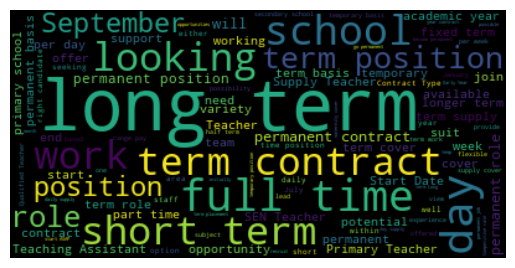

In [36]:
# Check most frequent words and then we'll do a basic regex for these frequently occurring terms
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(
                contract_refs[
                    "sentences_split"
                ].tolist()
                )

# Generate a word cloud image
wordcloud = WordCloud().generate(text)

# Display the generated image:

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")

In [37]:
analysis_utils.classify_contract_type('Care Assistant  Guaranteed minimum 20-hour contract Salary  £11per hour weekday evenings and  £12 per hour weekends Hours 5 00 pm to 10 00 pm evenings and alternate weekends Location  Chichester, Bognor Regis and surrounding areas.')

'Unknown'

In [38]:
contract_refs['classified_contract_type'] = contract_refs['sentences_split'].apply(analysis_utils.classify_contract_type)
contract_refs['classified_contract_type'].value_counts()

/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_88235/380081984.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  contract_refs['classified_contract_type'] = contract_refs['sentences_split'].apply(analysis_utils.classify_contract_type)


classified_contract_type
Permanent         8446
Unknown           4545
Temporary         2713
Apprenticeship       5
Name: count, dtype: int64

In [39]:
#Inspect the ones that couldn't be identified
contract_refs[contract_refs['classified_contract_type']=='Unknown']['sentences_split'].to_list()

[' Full-time Contract length  12 months Salary  £13.17-£13.50 per hour',
 ' Full-time Contract length  12 months Salary  £13.17-£13.50 per hour',
 ' Perks of this position are   Flexible working hours.',
 ' Short Term',
 ' 40hrs per weekpermanent contract An opportunity has become available for a qualified Early Years Educator to join a lovely private nursery',
 ' 40hrs per weekpermanent contract An opportunity has become available for a qualified Early Years Educator to join a lovely private nursery',
 ' and 6 months experience in an Early Years setting.',
 ' employee of the month  and much more.',
 ' employee of the month and  much more.',
 ' including a 100% completion rate of the Monthly Hand.',
 " including employee of the month vouchers and staff sickness bonus's.",
 ' including weekend work \ufeff\ufeffStarting salary £9.65 per hour with our aim to have all',
 ' increasing with service To apply to this Montessori Nursery Teacher position please submit your CV using the apply now

In [40]:
contract_refs['classified_contract_type'].value_counts()

classified_contract_type
Permanent         8446
Unknown           4545
Temporary         2713
Apprenticeship       5
Name: count, dtype: int64

Some IDs get matched to more than one contract type, so we need to pick just one for our output.

In [42]:
counts = contract_refs.groupby(['id', 'classified_contract_type']).size().reset_index(name='count')

# Find the most frequent 'classified_contract_type' for each job
most_frequent = counts.loc[counts.groupby('id')['count'].idxmax()]

# gather all the different contract types that were applied to the same job
contract_df = contract_refs.groupby('id')['classified_contract_type'].agg(list).reset_index()

def determine_contract_type(types: List[str]):
    if 'Temporary' in types:
        return 'Temporary'
    else:
        # Count occurrences of each type
        type_counts = pd.Series(types).value_counts()
        most_common = type_counts.idxmax()
        if len(type_counts) == 1:  # Only one unique type
            return most_common
        elif len(type_counts) > 1:
            # If the list contains more than one type, we need to check the most common
            if most_common == 'Permanent' or most_common == 'Unknown':
                return most_common
            else:
                return 'Unknown'  # Fallback to 'Unknown' if neither 'Temporary' nor most frequent matches
        return 'Unknown'

contract_df['final_contract_type'] = contract_df['classified_contract_type'].apply(determine_contract_type)

In [43]:
contract_df

,id,classified_contract_type,final_contract_type
0,41655872,"[Permanent, Unknown]",Permanent
1,41666008,[Temporary],Temporary
2,41669227,"[Permanent, Permanent]",Permanent
3,41670201,"[Permanent, Unknown, Unknown]",Unknown
4,41670315,"[Permanent, Permanent]",Permanent
...,...,...,...
7019,51568455,"[Apprenticeship, Apprenticeship, Permanent]",Unknown
7020,51568743,[Permanent],Permanent
7021,51569123,[Unknown],Unknown
7022,51569443,[Permanent],Permanent


In [44]:
afs_sample_enhanced_contract = pd.merge(afs_sample_enhanced, contract_df[['id', 'final_contract_type']], on='id', how='left')

In [45]:
afs_sample_enhanced_contract['final_contract_type'].value_counts(dropna=False)

final_contract_type
NaN               12872
Permanent          3481
Unknown            2101
Temporary          1441
Apprenticeship        1
Name: count, dtype: int64

In [46]:
afs_sample_enhanced_contract['final_contract_type'] = afs_sample_enhanced_contract['final_contract_type'].fillna('Unknown')

In [47]:
afs_sample_enhanced_contract['final_contract_type'].value_counts(dropna=False)

final_contract_type
Unknown           14973
Permanent          3481
Temporary          1441
Apprenticeship        1
Name: count, dtype: int64

In [48]:
afs_sample_enhanced_contract.groupby(['sector_group', 'final_contract_type']).size()

sector_group                      final_contract_type
Early Years Practitioner          Apprenticeship            1
                                  Permanent               535
                                  Temporary               218
                                  Unknown                2562
Primary/Secondary School Teacher  Permanent               865
                                  Temporary               332
                                  Unknown                2119
Special Needs Teacher             Permanent               641
                                  Temporary               222
                                  Unknown                2453
Supply Teacher                    Permanent               646
                                  Temporary               273
                                  Unknown                2397
Teaching Assistant                Permanent               663
                                  Temporary               257
                

In [49]:
contract_prop_df = afs_sample_enhanced_contract.groupby(['sector_group', 'final_contract_type']).size().unstack(fill_value=0)
contract_prop_df

final_contract_type,Apprenticeship,Permanent,Temporary,Unknown
sector_group,,,,
Early Years Practitioner,1,535,218,2562
Primary/Secondary School Teacher,0,865,332,2119
Special Needs Teacher,0,641,222,2453
Supply Teacher,0,646,273,2397
Teaching Assistant,0,663,257,2396
"Waiter, Retail Assistant",0,131,139,3046


## Output for slide 8 (proportional bars of contract type by sector)

In [50]:
contract_prop_df.to_csv('outputs/sector_contract_type.csv')
save_to_s3(BUCKET_NAME, contract_prop_df, f'{S3_OUT_PATH}/sector_contract_type.csv')

2024-09-23 11:10:38,981 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/early_years/flourish_tables/sector_contract_type.csv ...


# Extracting hours

Not in the final analysis.

In [ ]:
hours_refs = processed_ads[processed_ads['subcategory']=='HOURS']
hours_refs

In [ ]:
hours_refs['hours_per_week'] = hours_refs['sentences_split'].apply(analysis_utils.match_hours_per_week)
hours_refs['working_days'] = hours_refs['sentences_split'].apply(analysis_utils.count_working_days)
hours_refs['is_full_time'] = hours_refs['sentences_split'].apply(analysis_utils.check_full_time)
hours_refs['hr_per_week_final'] = hours_refs.apply(analysis_utils.calculate_hr_per_week_final, axis=1)
hours_refs

In [ ]:
hours_refs['hr_per_week_final'].value_counts(dropna=False)